# Fed-BioMed example to use Logistic Regression on Flamby Heart Disease Dataset

This tutorial serves to show an example for using Fedbiomed with a Logistic Regression model from Scikit-learn.

The goal of the tutorial would be to predict whether a patient has a heart disease using Flamby Dataset. We are going to train two different models. One will be trained the federated way, which will use train data from 2 data centers, and will be validated on a third one. The centralized model will use the same data from the 2 centers, but will be trained in a centralized way. It will then again be validated with the third center.

In the end, we are going to compare the two models, which have used Federated Learning and Centralized Learning.


## Data

FLamby’s Fed-Heart-Disease is basically the UCI Heart Disease dataset repackaged as a cross-silo federated benchmark: each “client/center” is one hospital/source dataset, and the task is binary classification (no disease 0 vs disease 1–4, usually binarized to 0 vs >0).

The four data-centers are:

- Cleveland Clinic Foundation (USA)
- Hungarian Institute of Cardiology, Budapest (Hungary)
- University Hospital, Zurich (Switzerland)
- V.A. Medical Center, Long Beach, California (USA)

The dataset uses 13 main features, and as mentioned, 1 target. The Flamby version removes the headers, but the original headers are:

1. age 
2. sex (1 = male, 0 = female)
3. cp — chest pain type (categorical; often one-hot encoded)
4. trestbps — resting blood pressure (mm Hg)
5. chol — serum cholesterol (mg/dl)
6. fbs — fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
7. restecg — resting electrocardiographic results (categorical; often one-hot encoded)
8. thalach — maximum heart rate achieved
9. exang — exercise-induced angina (1 = yes, 0 = no)
10. oldpeak — ST depression induced by exercise relative to rest
11. slope — slope of the peak exercise ST segment (categorical/ordinal)
12. ca — number of major vessels (0–3) colored by fluoroscopy
13. thal — thalassemia / thal test result (categorical/ordinal)

The dataset is not perfect, and contains some missing values in some columns and/or centers. Therefore, we are going to do some preprocessing on the data, before actually adding it to the node and using it.

Another note we want to mention is that we are not going to use the data on the 4th Center - Switzerland - as it has both missing values and a huge class imbalance.

### Adding some imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split

### Downloading the files

In [2]:
import os
import urllib.request

urls = {
    "cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "hungarian": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "va":        "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data",
}

download_dir = "./data"
os.makedirs(download_dir, exist_ok=True)

path_cleveland = os.path.join(download_dir, "cleveland.csv")
path_hungarian = os.path.join(download_dir, "hungarian.csv")
path_va        = os.path.join(download_dir, "va.csv")

paths = {
    "cleveland": path_cleveland,
    "hungarian": path_hungarian,
    "va": path_va,
}

for name, url in urls.items():
    out_path = paths[name]
    urllib.request.urlretrieve(url, out_path)
    print(f"Downloaded {name} -> {out_path}")

Downloaded cleveland -> ./data/cleveland.csv
Downloaded hungarian -> ./data/hungarian.csv
Downloaded va -> ./data/va.csv


### Preprocessing the data 

The preprocessing we do is defined with the steps belov: 

1. Remove columns 11, 12 and 13. The columns for slope, ca and thal are non-existent or very sparse in most of the centers. Therefore, we directly remove those columns for safety.
2. Similarly, we remove the non-existing values, which are marked with a "?" in the Flamby dataset. If a sample has a non-existing value, we remove that sample.
3. We binarize the labels. The Flamby dataset marks the labels according to the level of sickness (0-Not sick, 4-Very sick). Instead of this, we simply try to predict whether a patient is sick or not (0-Not sick, 1-Sick).
4. We one-hat encode the categorical features. This means that if a categorical feature has more than 1 value, we convert it to n-1 columns. For example, if the feature has 3 possible values, we convert it to two columns where:
   - 0 in both columns refer to value 1
   - 0 in first, 1 in second column refer to value 2
   - and 1 in first, 0 in second column refer to value 3

In [6]:
in_paths = [
    "./data/cleveland.csv",
    "./data/hungarian.csv",
    "./data/va.csv",
]

out_before_norm_paths = [
    "./data/cleveland_BEFORE_norm.csv",
    "./data/hungarian_BEFORE_norm.csv",
    "./data/va_BEFORE_norm.csv",
]

for in_path, out_before_norm in zip(in_paths, out_before_norm_paths):
    # load + clean
    df = pd.read_csv(in_path, header=None)
    df = df.replace("?", np.nan).drop(df.columns[[10, 11, 12]], axis=1).dropna(axis=0)
    df = df.apply(pd.to_numeric)

    label_col = df.columns[-1]

    # one-hot encode categorical columns 2 (cp) and 6 (restecg)
    df = pd.get_dummies(df, columns=df.columns[[2, 6]], drop_first=True)

    # convert dummy bool columns True/False -> 0/1
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int64)

    # binarize label 0 vs >0 -> 0/1
    df[label_col] = (df[label_col] > 0).astype(np.int64)

    # ensure label is the LAST column
    feature_cols = [c for c in df.columns if c != label_col]
    df = df[feature_cols + [label_col]]

    # save BEFORE normalization
    df.to_csv(out_before_norm, header=False, index=False)

    print(f"Saved before normalization: {out_before_norm}")
    print("Dummy bool cols converted:", list(bool_cols))
    print("Shape:", df.shape)
    print("-" * 60)

Saved before normalization: ./data/cleveland_BEFORE_norm.csv
Dummy bool cols converted: ['2_2.0', '2_3.0', '2_4.0', '6_1.0', '6_2.0']
Shape: (303, 14)
------------------------------------------------------------
Saved before normalization: ./data/hungarian_BEFORE_norm.csv
Dummy bool cols converted: ['2_2', '2_3', '2_4', '6_1', '6_2']
Shape: (261, 14)
------------------------------------------------------------
Saved before normalization: ./data/va_BEFORE_norm.csv
Dummy bool cols converted: ['2_2', '2_3', '2_4', '6_1', '6_2']
Shape: (130, 14)
------------------------------------------------------------


### Normalizing the data

We do normalization using the mean and standard deviation of all the training data from all centers (Cleveland and Hungarian in our case). This helps the model to generalize more and learn better. The VA dataset, which is used for validation, is also normalized with the same mean and standard deviation.

In [7]:
in_paths = [
    "./data/cleveland_BEFORE_norm.csv",
    "./data/hungarian_BEFORE_norm.csv",
    "./data/va_BEFORE_norm.csv",
]

out_paths = [
    "./data/cleveland_globally_normalized.csv",
    "./data/hungarian_globally_normalized.csv",
    "./data/va_globally_normalized.csv",
]

# ---- Load all ----
dfs = [pd.read_csv(p, header=None, names=list(range(14))) for p in in_paths]

label_col = dfs[0].columns[-1]
feature_cols = [c for c in dfs[0].columns if c != label_col]

# ---- Compute global mu/sigma from the first two (centers) ----
combined = pd.concat(dfs[:2], axis=0)
mu = combined[feature_cols].mean()
sigma = combined[feature_cols].std(ddof=0).replace(0, 1)

# ---- Normalize each dataframe using global stats + save ----
for df, out_path in zip(dfs, out_paths):
    df_norm = df.copy()
    df_norm[feature_cols] = (df_norm[feature_cols] - mu) / sigma
    df_norm.to_csv(out_path, header=False, index=False)
    print("Saved after GLOBAL normalization:", out_path)

Saved after GLOBAL normalization: ./data/cleveland_globally_normalized.csv
Saved after GLOBAL normalization: ./data/hungarian_globally_normalized.csv
Saved after GLOBAL normalization: ./data/va_globally_normalized.csv


Helper function to sanity check whether there is a class imbalance or not.

In our example, we can see there is some imbalance in the VA dataset.

In [8]:
def check_class_imbalance(y, *, name="y"):
    y = np.asarray(y)
    vals, counts = np.unique(y, return_counts=True)
    total = counts.sum()

    report = pd.DataFrame({
        "class": vals,
        "count": counts,
        "pct": (counts / total * 100).round(2),
    }).sort_values("count", ascending=False)

    print(f"\nClass distribution for {name} (n={total}):")
    print(report.to_string(index=False))

    maj = counts.max()
    min_ = counts.min()
    print(f"\nMajority: {maj} ({maj/total:.2%})")
    print(f"Minority: {min_} ({min_/total:.2%})")
    print(f"Imbalance ratio (maj/min): {maj / max(min_, 1):.2f}x")

    return report

report = check_class_imbalance(pd.read_csv("./data/va_globally_normalized.csv", header=None).iloc[:, 13].to_numpy(), name="target")
print(report.shape)


Class distribution for target (n=130):
 class  count   pct
     1    101 77.69
     0     29 22.31

Majority: 101 (77.69%)
Minority: 29 (22.31%)
Imbalance ratio (maj/min): 3.48x
(2, 3)


## Creating Nodes

To create the federated dataset, we follow the standard procedure for node creation/population of Fed-BioMed. 

we create a first node by using the commands

```shell
$ fedbiomed node -p node-1 start
```

We then populate the node with the data of first client:

```shell
$ fedbiomed node -d node-1 dataset add`
``` 

We select option 1 (csv) to add the cleveland_globally_normalized.csv inside the data folder. We use `flamby` as tag to save the selected dataset. In Fedbiomed, tags are used as identifiers by the researcher, to select the nodes and data that will participate in the federated training. 

We can check that the data has been added by executing `fedbiomed node -d node-1 dataset list`.

We repeat the same operations for node-2 for the hungarian dataset.

## Defining the Training Plan

The class `FedSGDClassifier` constitutes the Fed-BioMed wrapper for executing Federated Learning using Scikit-Learn `SGDClassifier` linear classifier with SGD training model. We create a new training plan class `LogisticRegressorTrainingPlan` that inherits from it. For a refresher on how Training Plans work in Fed-BioMed, please refer to our [Training Plan user guide](../../../user-guide/researcher/training-plan).

In scikit-learn Training Plans, you typically need to define only the `training_data` function, and optionally an `init_dependencies` function if your code requires additional module imports. 

A small reminder, that we are using hardcoded column indexes ti define the dataset in the `training_data` function, as we don't have column names in the Flamby dataset.

We are using Balanced Accuracy as our custom metric for measuring the performance. In order to add balanced accuracy as a custom metric, we need to override the `testing_step` function which is defined at the training plan. The `testing_step` is called at the end of each round when testing is done, and it should return the score of the test.

In [18]:
from fedbiomed.common.training_plans import FedSGDClassifier
from fedbiomed.common.dataset import TabularDataset
from fedbiomed.common.datamanager import DataManager

class LogisticRegressorTrainingPlan(FedSGDClassifier):
    def init_dependencies(self):
        """Define additional dependencies."""
        return [
                "from fedbiomed.common.dataset import TabularDataset",
                "from sklearn.metrics import balanced_accuracy_score",
                "import numpy as np",
        ]

    def training_data(self):
        dataset = TabularDataset(input_columns=list(range(0,13)), target_columns=13)
        return DataManager(dataset=dataset)

    def testing_step(self, data, target):
        preds = self.model().predict(data)
        balanced_accuracy = balanced_accuracy_score(y_pred=preds, y_true=target)
        return balanced_accuracy

## Defining the Model and Training Arguments

### Model arguments

`model_args` is a dictionary with the arguments related to the model, that will be passed to the `SGDClassifier` constructor.

**IMPORTANT** For classification tasks, you are **required** to specify the following field:
- `n_features`: the number of features in each input sample
- `n_classes`: the number of classes predicted

### Training arguments

`training_args` is a dictionary containing the arguments for the training routine (e.g. batch size, learning rate, epochs, etc.). This will be passed to the routine on the node side.

**IMPORTANT** We need to define the `loss` parameter as `log_loss` in order to train a Logistic Regression model. The learning rate should also be constant for consistency in federated learning using SkLearn. All other parameters can be tweaked around with.

In [19]:
model_args = {
    'n_features':13,
    'n_classes':2,
    'loss': 'log_loss',
    'learning_rate': "constant", 
    'eta0': 0.01,
    # 'alpha': 1e-4,
    # 'penalty': "l2",
    # 'random_state':RANDOM_SEED,
}

training_args = {
    # 'shuffle': True,
    'loader_args': { 'batch_size': 16, },
    'epochs': 2,
    'dry_run': False,
    'test_ratio' : 0.2,
    'test_batch_size': 16,
    'test_on_global_updates': True,
    'test_on_local_updates': True,
}

### Defining and Launching the Experiment

The experiment can be now defined, by providing the `flamby` tag, and running the local training on nodes with training plan defined in `training_plan_path`, standard `aggregator` (FedAvg) and `client_selection_strategy` (all nodes used). Federated learning is going to be performed through 20 optimization rounds.

In [20]:
from fedbiomed.researcher.federated_workflows import Experiment
from fedbiomed.researcher.aggregators.fedavg import FedAverage

tags = ['flamby']
num_rounds = 50

exp = Experiment(tags=tags,
                 model_args=model_args,
                 training_plan_class=LogisticRegressorTrainingPlan,
                 training_args=training_args,
                 round_limit=num_rounds,
                 aggregator=FedAverage(),
                 node_selection_strategy=None
                )

2026-02-24 15:12:44,856 fedbiomed INFO - Updating training data. This action will update FederatedDataset, and the nodes that will participate to the experiment.

2026-02-24 15:12:44,886 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-24 15:12:44,889 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-24 15:12:44,892 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2

2026-02-24 15:12:44,893 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_89269fb8-e88f-447b-bf40-6cff09f06a75

2026-02-24 15:12:44,915 fedbiomed DEBUG - Model file has been saved: /mnt/c/Users/adincer/Desktop/fedbiomed/fbm-researcher/var/experiments/Experiment_1004/model_3f7d6785-ea1e-406a-bd92-cf58571b5f19.py

2026-02-24 15:12:44,958 fedbiomed WARNING - Option share_persistent_buffers is not supported in SKLearnTrainingPlan, it will be ignored.

2026-02-24 15:12:44,959 fedbiomed DEBUG - Using native Sklearn Optimizer

In [21]:
exp.run()

2026-02-24 15:12:47,494 fedbiomed INFO - Sampled nodes in round 0 ['NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2', 'NODE_89269fb8-e88f-447b-bf40-6cff09f06a75']

2026-02-24 15:12:47,508 fedbiomed INFO - Sending request 
					 To: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-24 15:12:47,509 fedbiomed INFO - Sending request 
					 To: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-24 15:12:47,527 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-24 15:12:47,531 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

...

2026-02-24 15:14:33,647 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 1/4 (25%) | Samples: 16/52
 					 Custom: 0.666667 
					 ---------

2026-02-24 15:14:33,650 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 1/4 (25%) | Samples: 16/60
 					 Custom: 0.944444 
					 ---------

2026-02-24 15:14:33,756 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 4/4 (100%) | Samples: 52/52
 					 Custom: 1.000000 
					 ---------

2026-02-24 15:14:33,774 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 51 | Iteration: 4/4 (100%) | Samples: 60/60
 					 Custom: 0.750000 
					 ---------

50

### Plotting the Losses and the Accuracies

Below, we plot the accuracy and log loss for each node

In [22]:
nodes = exp.monitor()._metric_store.keys()
train_losses = {}
for node in nodes:
  train_losses[node] = list()
  for round in exp.monitor()._metric_store[node]['training']['Loss log_loss'].keys():
    round_loss = exp.monitor()._metric_store[node]['training']['Loss log_loss'][round]['values']
    train_losses[node].append(np.mean(round_loss))

balanced_accuracies = {}
for node in nodes:
    balanced_accuracies[node] = list()
    for round in exp.monitor()._metric_store[node]['testing_global_updates']['Custom'].keys():
      round_accs = exp.monitor()._metric_store[node]['testing_global_updates']['Custom'][round]['values']
      balanced_accuracies[node].append(np.mean(round_accs))

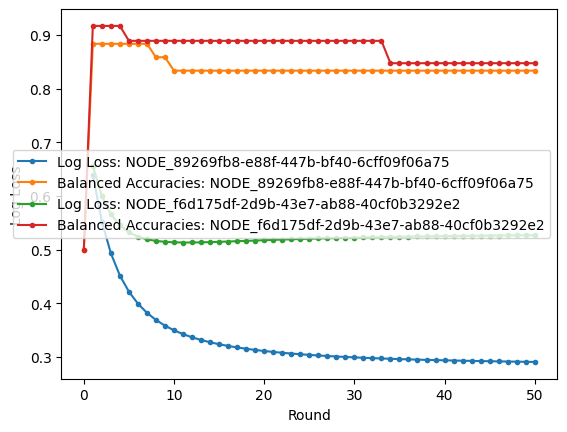

In [23]:
for node in nodes:
  plt.plot(range(1,exp.round_limit()+1), train_losses[node], '.-', label=f'Log Loss: {node}')
  plt.plot(range(exp.round_limit()+1), balanced_accuracies[node], '.-', label=f'Balanced Accuracies: {node}')
_ = plt.xlabel('Round')
_ = plt.ylabel('Log Loss')
plt.legend()

### Evaluating the performance of the model using the validation dataset

In this step, we are going to validate our federated model using the dataset from the third center (VA).

We again use the Balanced Accuracy metric and plot a Confusion Matrix to see our result.

In [24]:
federated_model = exp.training_plan().model()

Balanced accuracy: 0.6546602936155685

Classification report:
               precision    recall  f1-score   support

           0     0.4167    0.5172    0.4615        29
           1     0.8511    0.7921    0.8205       101

    accuracy                         0.7308       130
   macro avg     0.6339    0.6547    0.6410       130
weighted avg     0.7542    0.7308    0.7404       130



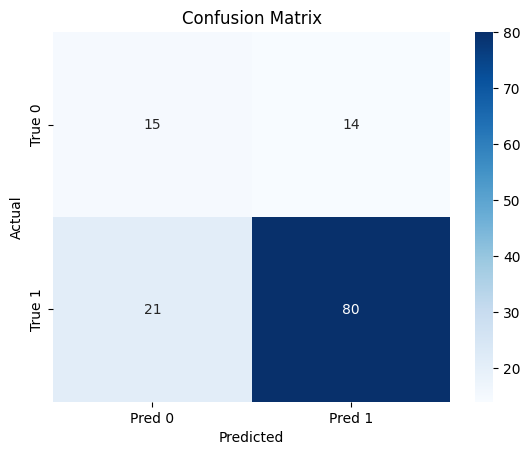

In [30]:
path_va = "./data/va_globally_normalized.csv"

df_va = pd.read_csv(path_va, header=None)

y_true = df_va.iloc[:, -1].to_numpy().astype(int)
X = df_va.drop(df.columns[-1], axis=1).to_numpy().astype(np.float32)

# Predict
y_pred = federated_model.predict(X)

bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Centralized Model

We will continue with defining a centralized model with same parameters, and try to compare it with the federated model.

### We define the same parameters

We accumulate the data in a central dataframe (node). We are going to use the centralized data for training.

In [27]:
path1 = "./data/cleveland_globally_normalized.csv"
path2 = "./data/hungarian_globally_normalized.csv"

df_c1 = pd.read_csv(path1, header=None)
df_c2 = pd.read_csv(path2, header=None)

df_centralized = pd.concat((df_c1, df_c2), axis=0)

X = df_centralized.iloc[:, :-1].to_numpy(dtype=np.float64)
y = df_centralized.iloc[:, -1].to_numpy(dtype=np.int64)

# Train/test split (test_ratio = 0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

centralized_model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,           # with partial_fit / epoch loop; or set higher if using fit()
    tol=None,             # disable early stopping so epochs are controlled externally
    average=True,
    shuffle=False,
)

### We launch a centralized training

We use the same parameters, and we plot the result for log losses and accuracy.

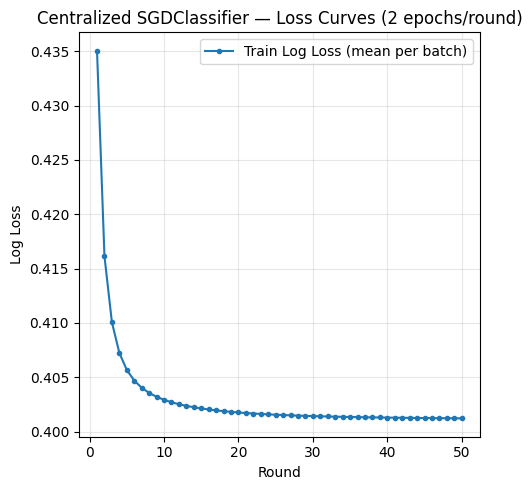

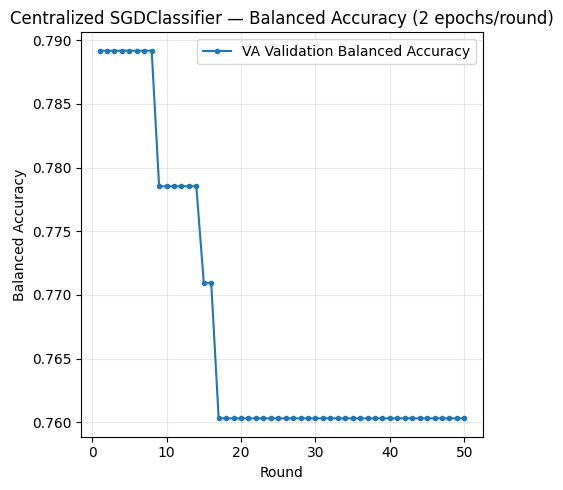

In [28]:
# -----------------------------
# TRAINING SETTINGS
# -----------------------------
rounds = 50
epochs_per_round = 2
batch_size = 16
classes = np.array([0, 1], dtype=np.int64)

def iterate_minibatches_in_order(X, y, batch_size):
    n = len(X)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield X[start:end], y[start:end]

def mean_batch_log_loss(centralized_model, X, y, batch_size, classes):
    # Average of per-batch log_loss values (closer to "training batch loss" logging)
    losses = []
    for xb, yb in iterate_minibatches_in_order(X, y, batch_size):
        proba = centralized_model.predict_proba(xb)
        losses.append(log_loss(yb, proba, labels=classes))
    return float(np.mean(losses)) if losses else np.nan

train_log_losses = []
test_bal_accs = []

first_fit_done = False

# -----------------------------
# TRAIN LOOP: rounds x epochs_per_round
# -----------------------------
for r in range(1, rounds + 1):
    for e in range(epochs_per_round):
        for xb, yb in iterate_minibatches_in_order(X_train, y_train, batch_size):
            if not first_fit_done:
                centralized_model.partial_fit(xb, yb, classes=classes)
                first_fit_done = True
            else:
                centralized_model.partial_fit(xb, yb)

    # Mean of per-batch log losses (often closer to what you saw)
    ll_mean_batch = mean_batch_log_loss(centralized_model, X_train, y_train, batch_size, classes)
    train_log_losses.append(ll_mean_batch)
            
    # Balanced Accuracies
    y_test_pred = centralized_model.predict(X_test)
    test_bal_accs.append(balanced_accuracy_score(y_test, y_test_pred))

# -----------------------------
# PLOT
# -----------------------------
x = np.arange(1, rounds + 1)

# Plot 1: losses
plt.figure(figsize=(5, 5))
plt.plot(x, train_log_losses, ".-", label="Train Log Loss (mean per batch)")
plt.xlabel("Round")
plt.ylabel("Log Loss")
plt.title(f"Centralized SGDClassifier — Loss Curves ({epochs_per_round} epochs/round)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: balanced accuracies
plt.figure(figsize=(5, 5))
plt.plot(x, test_bal_accs, ".-", label="VA Validation Balanced Accuracy")
plt.xlabel("Round")
plt.ylabel("Balanced Accuracy")
plt.title(f"Centralized SGDClassifier — Balanced Accuracy ({epochs_per_round} epochs/round)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### We plot the confusion matrix and see we have obtained a similar resilt with the centralized model

TN=10, FP=19, FN=13, TP=88
Final VA balanced accuracy: 0.608057357459884

Classification report:
               precision    recall  f1-score   support

           0     0.4348    0.3448    0.3846        29
           1     0.8224    0.8713    0.8462       101

    accuracy                         0.7538       130
   macro avg     0.6286    0.6081    0.6154       130
weighted avg     0.7360    0.7538    0.7432       130



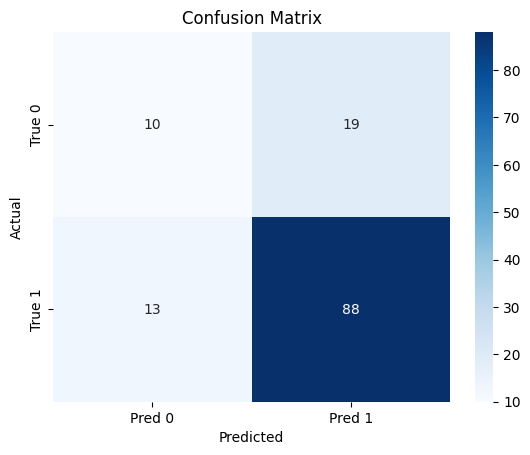

In [31]:
# -----------------------------
# CONFUSION MATRIX on VA (final model)
# -----------------------------

X_va = df_va.iloc[:, :-1].to_numpy(dtype=np.float64)
y_va = df_va.iloc[:, -1].to_numpy(dtype=np.int64)

va_pred_final = centralized_model.predict(X_va)
cm = confusion_matrix(y_va, va_pred_final, labels=classes)

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("Final VA balanced accuracy:", balanced_accuracy_score(y_va, va_pred_final))
print("\nClassification report:\n", classification_report(y_va, va_pred_final, digits=4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## BONUS - Some additional training plots, in case we want to experiment with different parameters

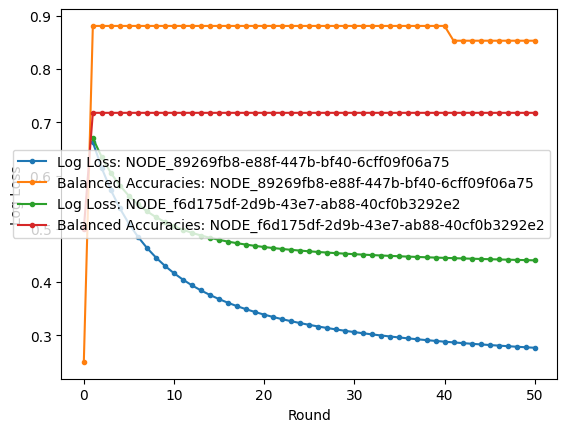

2026-02-24 10:06:49,707 fedbiomed WARNING - Node NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 is disconnected. Request/task that are created for this node will be flushed

2026-02-24 10:06:57,706 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-24 10:06:57,707 fedbiomed INFO - Node NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 is back online!

In [53]:
# Globally normalized

# Epochs 1
# Rounds 50

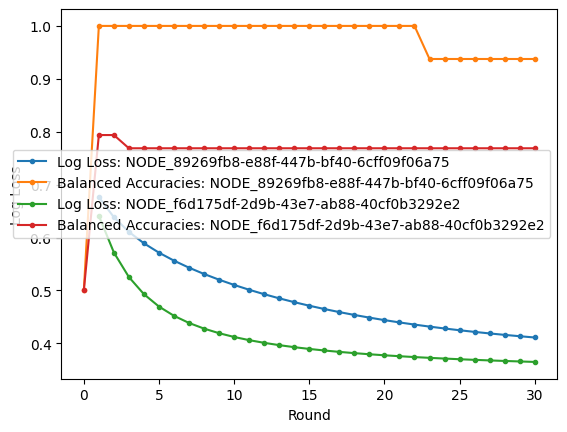

In [45]:
# Globally normalized

# Epochs 2
# Rounds 30

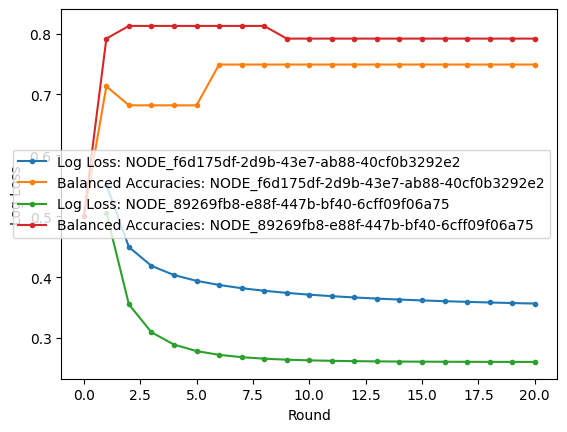

In [122]:
# Epochs 10
# Rounds 20

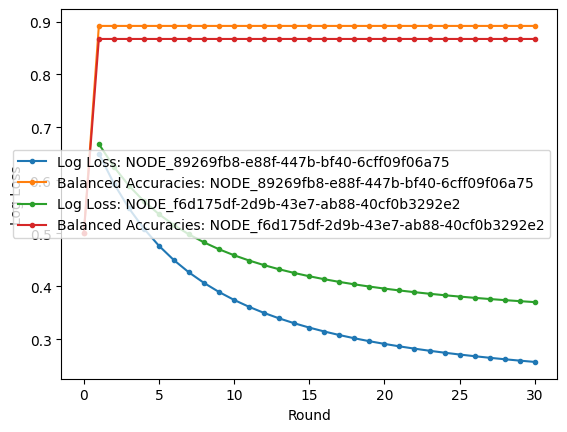

In [132]:
# Epochs 1
# Rounds 30